<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/SVM_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machines (SVM): From Beginner to Advanced

## 1. Introduction to Support Vector Machines (SVM)

Support Vector Machines (SVMs) are powerful, versatile machine learning models capable of performing linear or non-linear classification, regression, and even outlier detection. They are particularly well-suited for classification of complex small-to-medium sized datasets.

### The Core Idea
The fundamental idea behind SVM is to find the best possible **hyperplane** that separates different classes of data points in a high-dimensional space. The 'best' hyperplane is defined as the one with the largest **margin** between the closest training data points of any class. These closest points are called **support vectors**.



### Key Concepts:
1.  **Hyperplane**: In a 2D space, it's a line; in 3D, it's a plane; and in higher dimensions, it's a hyperplane. Its job is to separate data points into different classes.
2.  **Margin**: The distance between the hyperplane and the nearest data point from either class (the support vectors). SVM aims to maximize this margin.
3.  **Support Vectors**: The training examples that are closest to the decision boundary (hyperplane). These points are crucial because they directly influence the position and orientation of the hyperplane. If they are removed, the hyperplane might change. Other data points further away from the margin do not affect the hyperplane.


## 2. Linear SVM for Binary Classification

Let's start with the simplest case: linearly separable data where two classes can be perfectly separated by a straight line (or hyperplane).


### 2.1. Generating Linearly Separable Data

First, we'll create some synthetic data that can be easily separated by a linear decision boundary.

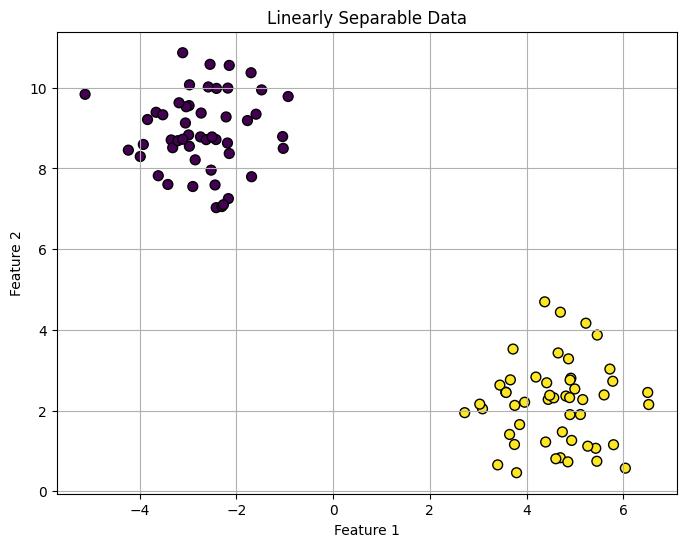

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# Generate some linearly separable data
X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.0)

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linearly Separable Data')
plt.grid(True)
plt.show()


### 2.2. Training a Linear SVM Model

We will use `sklearn.svm.SVC` with a `linear` kernel to train our model. SVC stands for Support Vector Classifier.

In [2]:
# Create a Linear SVM classifier
svm_linear = SVC(kernel='linear', C=1e5) # C is a regularization parameter, we'll discuss it later
svm_linear.fit(X, y)

# Get the support vectors
support_vectors = svm_linear.support_vectors_

print(f"Number of support vectors: {len(support_vectors)}")
print("Support vectors:\n", support_vectors)


Number of support vectors: 2
Support vectors:
 [[-1.03130358  8.49601591]
 [ 4.375222    4.69333885]]


### 2.3. Visualizing the Decision Boundary and Support Vectors

Now, let's visualize the hyperplane (decision boundary), the margins, and the support vectors. This helps in understanding how SVM separates the classes.

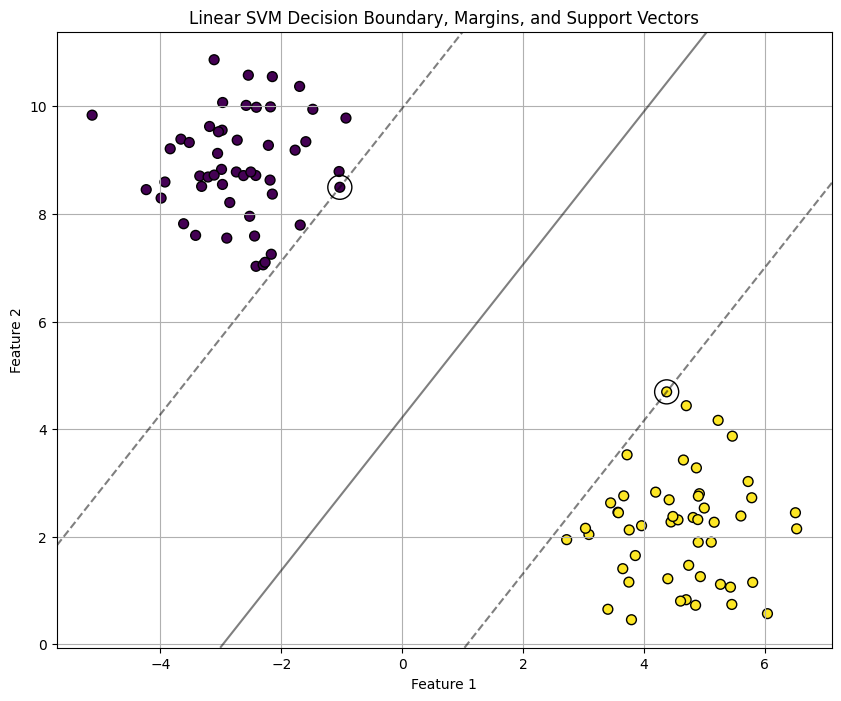

In [3]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='black')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolor='k')
plot_svc_decision_function(svm_linear)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear SVM Decision Boundary, Margins, and Support Vectors')
plt.grid(True)
plt.show()


## 3. The C Parameter (Regularization) and Soft Margin SVM

In the previous example, we used `C=1e5`, which is a very large value. This forces the SVM to make as few misclassifications as possible, resulting in a "hard margin" — meaning no data points are allowed to cross the margin. This works well for perfectly linearly separable data.

However, in most real-world scenarios, data is not perfectly linearly separable, or it might contain outliers. A hard margin SVM would fail to find a separating hyperplane or would be overly sensitive to noise. This is where the concept of a **Soft Margin SVM** and the regularization parameter `C` come into play.

### What is the `C` Parameter?

`C` is a regularization parameter that controls the trade-off between maximizing the margin and minimizing the classification error (i.e., allowing some misclassifications or points within the margin).

*   **Small `C` (e.g., `C=0.1`)**: A small `C` value creates a larger margin but allows for more misclassifications (more tolerance for errors). It's a stronger regularization, leading to a simpler model that might underfit if too small.
*   **Large `C` (e.g., `C=100` or `C=1e5`)**: A large `C` value creates a smaller margin but aims for fewer misclassifications (less tolerance for errors). It's a weaker regularization, leading to a more complex model that might overfit if too large.

Let's demonstrate the effect of `C` using data that is not perfectly linearly separable.

### 3.1. Generating Data with Overlap

We'll create some synthetic data where the two classes slightly overlap, making a perfect linear separation impossible.

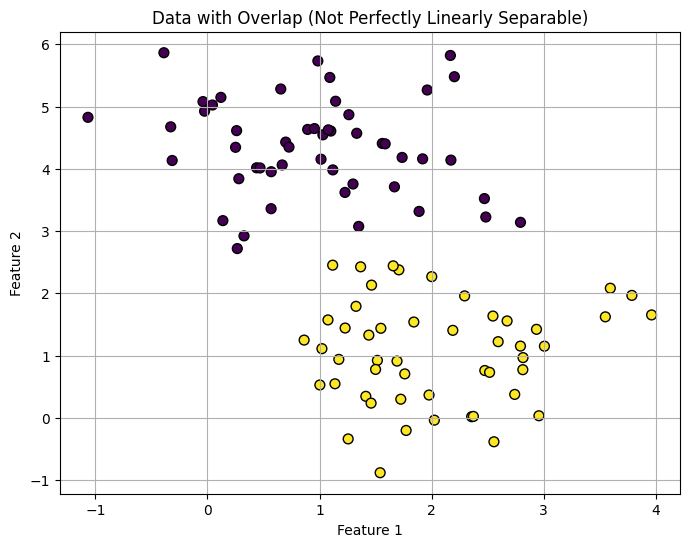

In [4]:
# Generate data with some overlap
X_overlap, y_overlap = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=0.8)

plt.figure(figsize=(8, 6))
plt.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, s=50, cmap='viridis', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data with Overlap (Not Perfectly Linearly Separable)')
plt.grid(True)
plt.show()


### 3.2. Comparing Different `C` Values

Let's train SVMs with different `C` values and observe their decision boundaries and support vectors.

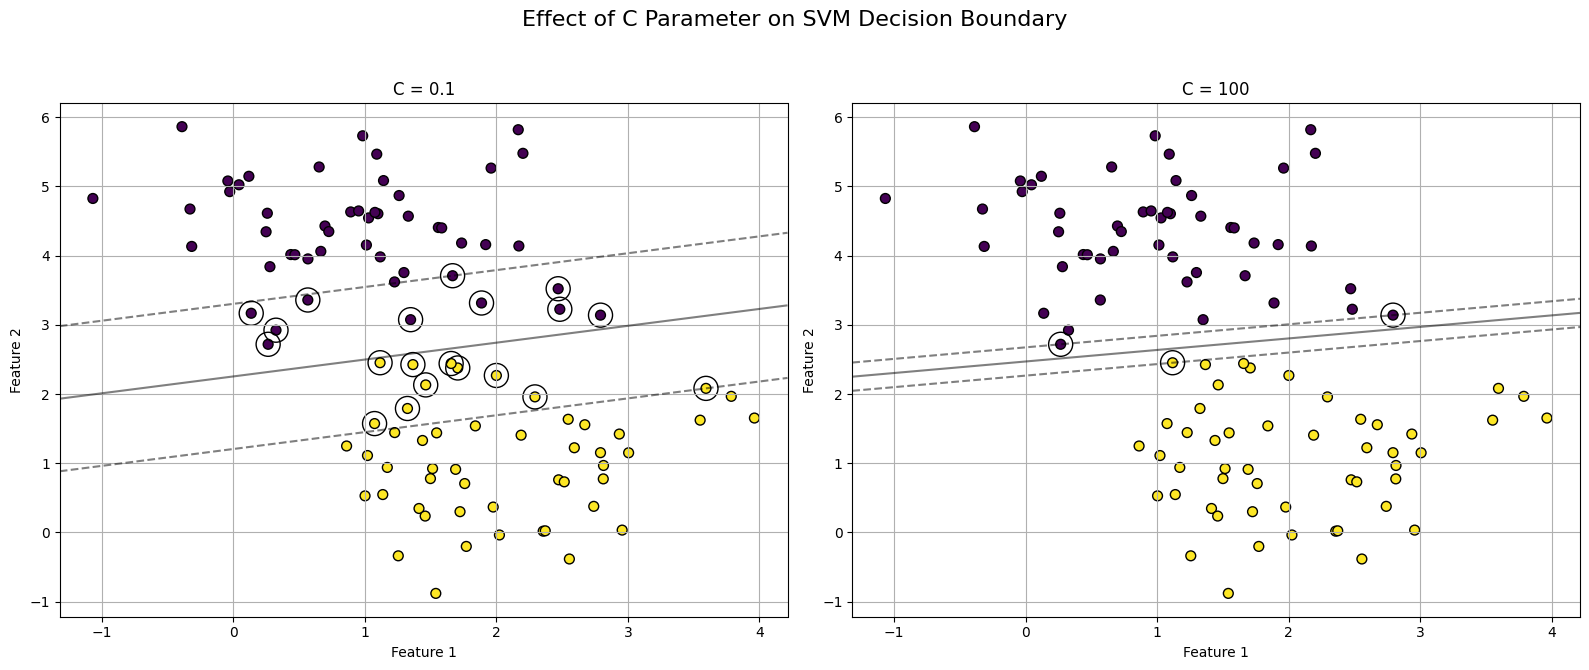

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Effect of C Parameter on SVM Decision Boundary', fontsize=16)

for axi, C_val in zip(ax, [0.1, 100]):
    model = SVC(kernel='linear', C=C_val).fit(X_overlap, y_overlap)
    axi.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap, s=50, cmap='viridis', edgecolor='k')
    plot_svc_decision_function(model, axi)
    axi.set_title(f'C = {C_val}')
    axi.set_xlabel('Feature 1')
    axi.set_ylabel('Feature 2')
    axi.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Explanation of the Plots:

*   **Left Plot (`C=0.1`, Small C)**:
    *   The margin is wider.
    *   There are more data points (including misclassified ones) that fall within the margin or on the wrong side of the decision boundary.
    *   This model prioritizes a larger margin, even if it means accepting more training errors. It's a more generalized model, less prone to overfitting.

*   **Right Plot (`C=100`, Large C)**:
    *   The margin is narrower.
    *   Fewer data points are allowed within the margin or on the wrong side.
    *   This model tries to classify every training point correctly, even if it means a smaller margin. It's a more complex model, potentially more prone to overfitting, especially if the data contains noise.

The choice of `C` is a crucial hyperparameter that needs to be tuned, often using techniques like cross-validation, to achieve the best generalization performance on unseen data.

## 4. Non-linear SVM and the Kernel Trick

So far, we've dealt with data that is either linearly separable or nearly linearly separable. But what if the data cannot be separated by a straight line or a simple hyperplane in its original feature space? This is where the **Kernel Trick** comes into play, allowing SVMs to perform non-linear classification.

### The Core Idea: Mapping to Higher Dimensions

The kernel trick allows SVM to implicitly map the input data into a higher-dimensional feature space where it might become linearly separable, without actually calculating the coordinates of the data in that higher-dimensional space. This mapping is done by using a **kernel function**.

Imagine taking data that is circularly distributed in 2D and projecting it into 3D. In 3D, it might be possible to separate the classes with a plane. The kernel function calculates the dot product between two vectors in the high-dimensional space without ever explicitly transforming them into that space.


### Common Kernel Functions:

1.  **Linear Kernel** (`kernel='linear'`): We've already seen this. It's used for linearly separable data and performs no transformation.
    *   $K(x_i, x_j) = x_i^T x_j$
2.  **Polynomial Kernel** (`kernel='poly'`): Used for curved or polynomial decision boundaries.
    *   $K(x_i, x_j) = (\gamma x_i^T x_j + r)^d$
3.  **Radial Basis Function (RBF) / Gaussian Kernel** (`kernel='rbf'`): This is one of the most popular and powerful kernels, suitable for a wide range of non-linear problems. It maps data into an infinite-dimensional space.
    *   $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$
4.  **Sigmoid Kernel** (`kernel='sigmoid'`): Similar to the activation function in neural networks.
    *   $K(x_i, x_j) = \tanh(\gamma x_i^T x_j + r)$

Here, $\gamma$ (gamma) is another hyperparameter that controls the influence of a single training example. A small $\gamma$ means a large radius of influence, while a large $\gamma$ means a small radius of influence. And $r$ (coef0) is an independent term in some kernels.

### 4.1. Generating Non-linear Data

Let's create some data that is clearly not linearly separable, such as concentric circles.

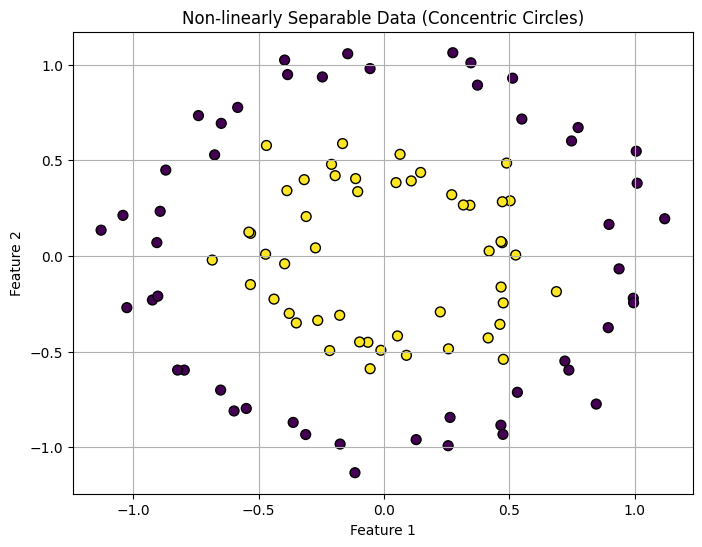

In [6]:
from sklearn.datasets import make_circles

# Generate non-linearly separable data (concentric circles)
X_nonlinear, y_nonlinear = make_circles(n_samples=100, factor=0.5, noise=0.08, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, s=50, cmap='viridis', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Non-linearly Separable Data (Concentric Circles)')
plt.grid(True)
plt.show()


### 4.2. Training an SVM with RBF Kernel

Now, we'll train an SVM using the Radial Basis Function (RBF) kernel to classify this non-linear data. Note that a linear SVM would perform very poorly on this dataset.

In [7]:
# Train an SVM with RBF kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='auto', random_state=42) # C and gamma are hyperparameters
svm_rbf.fit(X_nonlinear, y_nonlinear)

print(f"Number of support vectors with RBF kernel: {len(svm_rbf.support_vectors_)}")


Number of support vectors with RBF kernel: 52


### 4.3. Visualizing the Non-linear Decision Boundary

Let's visualize the decision boundary created by the RBF kernel. You'll see it's no longer a straight line.

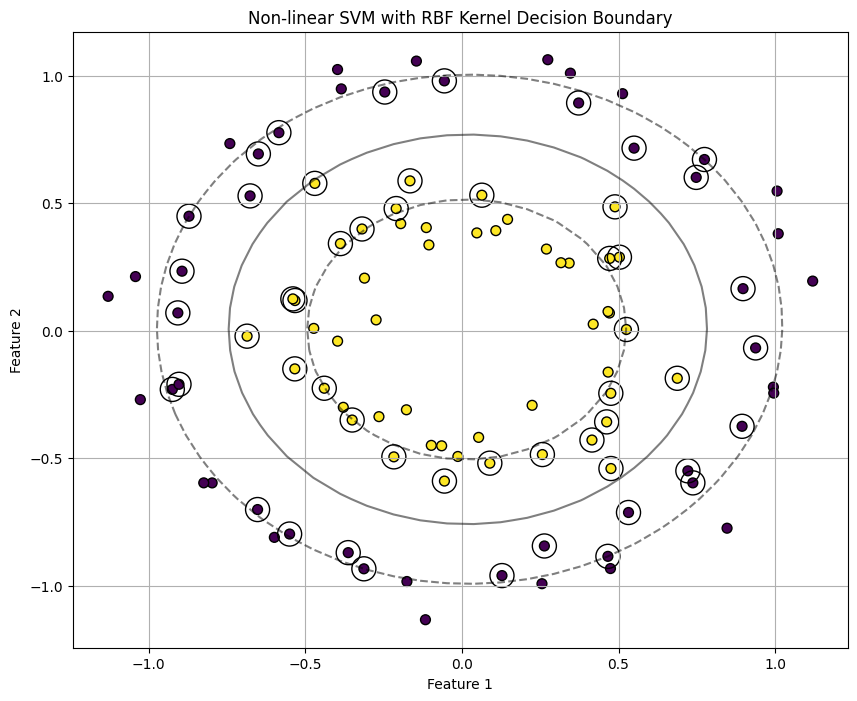

In [8]:
plt.figure(figsize=(10, 8))
plt.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, s=50, cmap='viridis', edgecolor='k')
plot_svc_decision_function(svm_rbf) # Reusing the plotting function
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Non-linear SVM with RBF Kernel Decision Boundary')
plt.grid(True)
plt.show()


As you can see, the RBF kernel successfully created a circular decision boundary that effectively separates the two classes. This demonstrates the power of the kernel trick in allowing SVMs to handle complex, non-linear patterns in data. In the next section, we'll explore the `gamma` parameter and its impact.

### 4.4. The `gamma` Parameter in RBF Kernel

For the RBF kernel, the `gamma` parameter ($\gamma$) defines how far the influence of a single training example reaches. It effectively controls the shape of the 'bumps' or curves in the decision boundary.

*   **Small `gamma`**: A small `gamma` value means a large radius of influence. The decision boundary will be smooth and broadly defined, potentially leading to underfitting if it's too small.
*   **Large `gamma`**: A large `gamma` value means a small radius of influence. The decision boundary will be more wiggly and closely follow individual data points, potentially leading to overfitting if it's too large.

Let's observe the effect of different `gamma` values on the same non-linearly separable data.

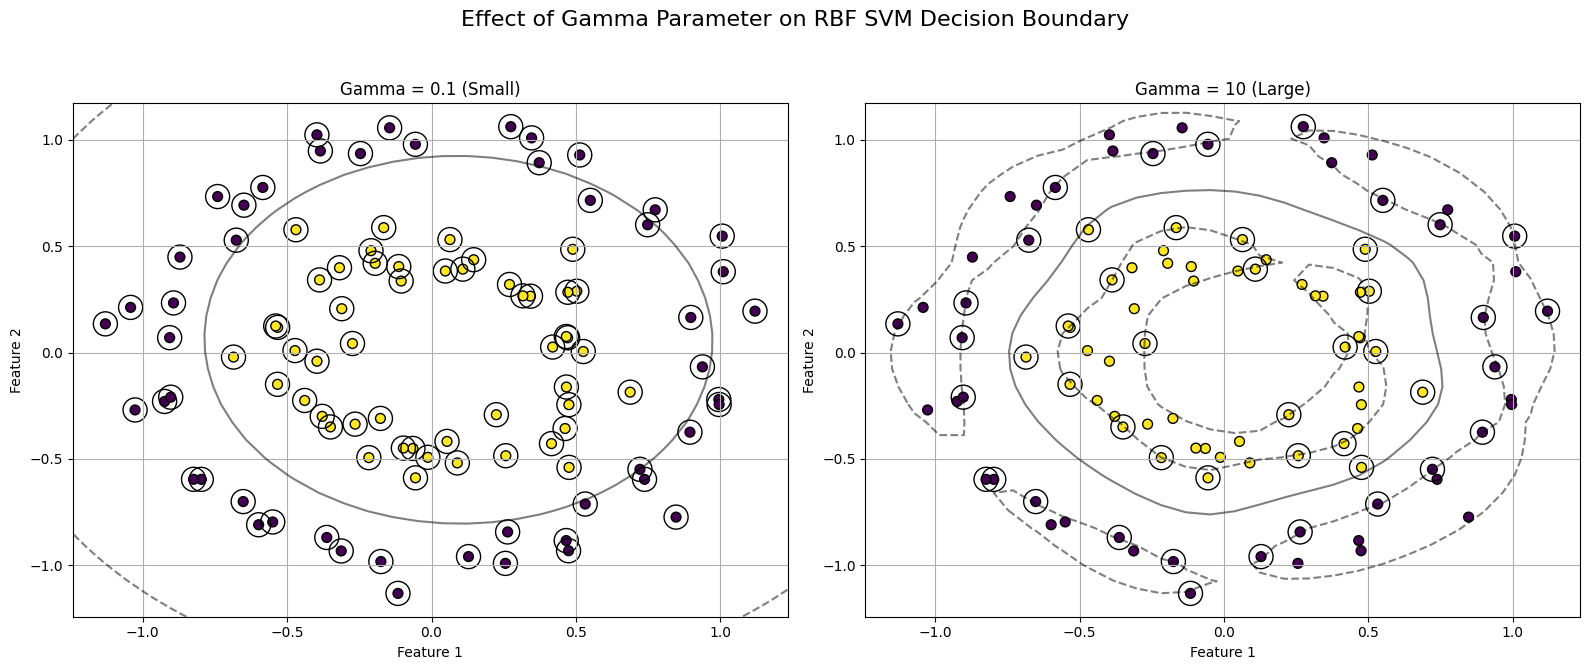

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Effect of Gamma Parameter on RBF SVM Decision Boundary', fontsize=16)

# Smaller gamma
model_small_gamma = SVC(kernel='rbf', C=1, gamma=0.1, random_state=42).fit(X_nonlinear, y_nonlinear)
ax[0].scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, s=50, cmap='viridis', edgecolor='k')
plot_svc_decision_function(model_small_gamma, ax[0])
ax[0].set_title('Gamma = 0.1 (Small)')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
ax[0].grid(True)

# Larger gamma
model_large_gamma = SVC(kernel='rbf', C=1, gamma=10, random_state=42).fit(X_nonlinear, y_nonlinear)
ax[1].scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, s=50, cmap='viridis', edgecolor='k')
plot_svc_decision_function(model_large_gamma, ax[1])
ax[1].set_title('Gamma = 10 (Large)')
ax[1].set_xlabel('Feature 1')
ax[1].set_ylabel('Feature 2')
ax[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Explanation of Gamma's Effect:

*   **Left Plot (`gamma=0.1`, Small Gamma)**:
    *   The decision boundary is smoother and more generalized. It tries to capture the overall pattern without being too sensitive to individual data points.
    *   This might lead to a higher bias and potentially underfit if the underlying pattern is very complex.

*   **Right Plot (`gamma=10`, Large Gamma)**:
    *   The decision boundary is much more intricate and follows the contours of the individual data points more closely.
    *   It tries to perfectly classify each training point, which can lead to lower bias but higher variance, potentially overfitting the training data and performing poorly on unseen data.

Finding the right `gamma` value, along with `C`, is crucial for the optimal performance of RBF kernel SVMs. This typically involves **hyperparameter tuning** using techniques like grid search or randomized search with cross-validation.

## 5. Multi-Class Classification with SVM

So far, we've focused on binary classification (two classes). How do SVMs handle problems with more than two classes? There are primarily two strategies:

1.  **One-vs-Rest (OvR) or One-vs-All (OvA)**:
    *   This strategy trains $N$ separate binary classifiers for an $N$-class problem. Each classifier distinguishes one class from all the remaining $N-1$ classes.
    *   For a new instance, the class that yields the highest score from its respective classifier is chosen.
    *   `sklearn.svm.SVC` uses this strategy by default (controlled by `decision_function_shape='ovr'`).

2.  **One-vs-One (OvO)**:
    *   This strategy trains a binary classifier for every unique pair of classes. For an $N$-class problem, this means training $N(N-1)/2$ classifiers.
    *   For a new instance, it's classified by all classifiers, and the class that gets the most 'votes' wins.
    *   This strategy is generally preferred for `SVC` because it trains faster on larger datasets, as each classifier only needs to be trained on a subset of the training data.
    *   You can set `decision_function_shape='ovo'` in `sklearn.svm.SVC` to use this strategy.

### 5.1. Example: Multi-class SVM with Iris Dataset

Let's use the famous Iris dataset, which has three classes, to demonstrate multi-class classification with SVM.

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data[:, :2], iris.target # Using only the first two features for visualization

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# Train an SVM classifier for multi-class problem (RBF kernel)
svm_multi = SVC(kernel='rbf', C=1, gamma='auto', random_state=42)
svm_multi.fit(X_train, y_train)

# Make predictions
y_pred = svm_multi.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Multi-class SVM on Iris dataset: {accuracy:.2f}")


Accuracy of Multi-class SVM on Iris dataset: 0.80


### 5.2. Visualizing Multi-class Decision Boundaries

Visualizing multi-class decision boundaries requires plotting regions for each class.

## 6. Support Vector Regression (SVR)

Just as Support Vector Machines (SVMs) can be used for classification, their principles can also be extended to solve regression problems, in which case they are called **Support Vector Regression (SVR)**. The core idea is similar: instead of trying to fit the largest possible street between two classes, SVR tries to fit as many instances as possible within an 'epsilon' margin while limiting margin violations (i.e., data points outside the margin).

### Key Concepts of SVR:

*   **Epsilon ($\epsilon$)**: This parameter defines a margin of tolerance around the predicted value. No penalty is associated with errors within this margin. This is a unique feature of SVR, aiming to find a function that deviates from the training data by no more than $\epsilon$.
*   **C Parameter**: Similar to SVC, `C` is a regularization parameter that controls the trade-off between the flatness of the function (avoiding overfitting) and the amount of error tolerance (allowing points outside the $\epsilon$-tube).
*   **Kernel Trick**: SVR also benefits from the kernel trick, allowing it to model non-linear relationships, just like SVC.

### 6.1. Example: SVR with Synthetic Data

Let's create some simple synthetic data and fit an SVR model to it.

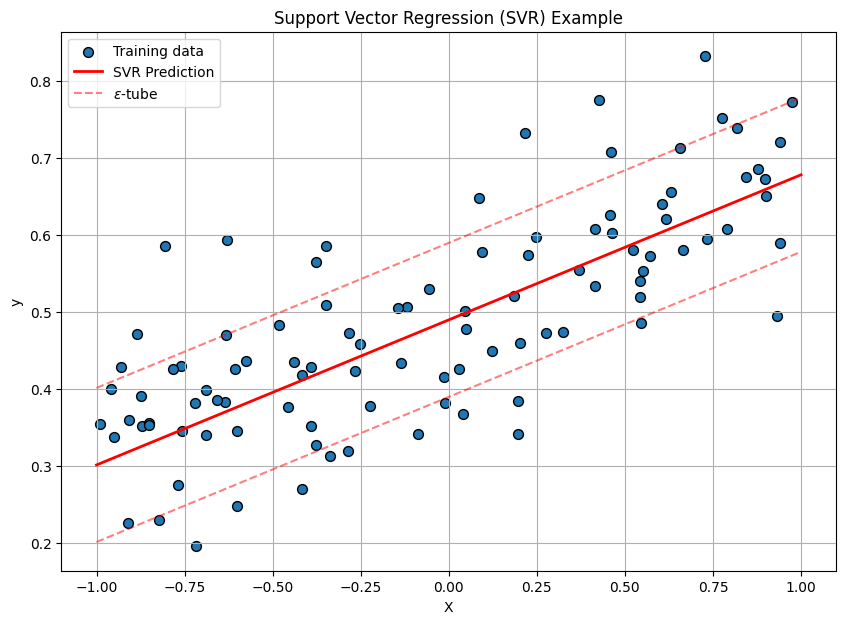

In [16]:
from sklearn.svm import SVR

# Generate some synthetic data for regression
np.random.seed(42)
X_reg = 2 * np.random.rand(100, 1) - 1
y_reg = (0.5 + 0.2 * X_reg + np.random.randn(100, 1) * 0.1).ravel()

# Fit an SVR model
svr_linear = SVR(kernel='linear', C=100, epsilon=0.1) # C and epsilon are hyperparameters
svr_linear.fit(X_reg, y_reg)

# Predict over a range to visualize the function
X_test_reg = np.linspace(-1, 1, 100).reshape(-1, 1)
y_pred_reg = svr_linear.predict(X_test_reg)

plt.figure(figsize=(10, 7))
plt.scatter(X_reg, y_reg, s=50, edgecolors='k', label='Training data')
plt.plot(X_test_reg, y_pred_reg, color='red', linewidth=2, label='SVR Prediction')

# Plot the epsilon-insensitive tube
plt.plot(X_test_reg, y_pred_reg + svr_linear.epsilon, 'r--', alpha=0.5, label=r'$\epsilon$-tube')
plt.plot(X_test_reg, y_pred_reg - svr_linear.epsilon, 'r--', alpha=0.5)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Support Vector Regression (SVR) Example')
plt.legend()
plt.grid(True)
plt.show()

### Explanation of the SVR Plot:

*   The **red line** represents the SVR model's prediction function.
*   The **red dashed lines** define the $\epsilon$-insensitive tube. SVR tries to fit the data such that as many data points as possible fall within this tube. Errors outside this tube are penalized.
*   The `epsilon` parameter controls the width of this tube. A larger $\epsilon$ means a wider tube, allowing more errors without penalty, leading to a flatter model. A smaller $\epsilon$ means a narrower tube, making the model more sensitive to individual data points.

SVR can also use different kernels (e.g., 'rbf', 'poly') to model non-linear relationships, making it a versatile tool for various regression tasks.

## 7. Hyperparameter Tuning for SVM

As we've seen, SVM models have several hyperparameters (`C`, `gamma`, `epsilon`, `kernel`, etc.) that significantly impact their performance. Finding the optimal combination of these parameters is crucial for building an effective SVM model. This process is known as **hyperparameter tuning**.

Common strategies for hyperparameter tuning include:

1.  **Grid Search Cross-Validation (`GridSearchCV`)**:
    *   This method exhaustively searches through a manually specified subset of the hyperparameter space.
    *   For each combination of hyperparameters, it trains and evaluates the model using cross-validation.
    *   The combination that yields the best performance (e.g., highest accuracy or lowest error) is selected.
    *   It is computationally expensive, especially with many hyperparameters or large ranges.

2.  **Randomized Search Cross-Validation (`RandomizedSearchCV`)**:
    *   Instead of trying all possible combinations, `RandomizedSearchCV` samples a fixed number of hyperparameter settings from a specified distribution.
    *   This can be more efficient than `GridSearchCV` when the search space is large, as it often finds a good combination much faster.

Let's demonstrate `GridSearchCV` to find the best `C` and `gamma` for our non-linear classification example (concentric circles).

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation accuracy: 1.00


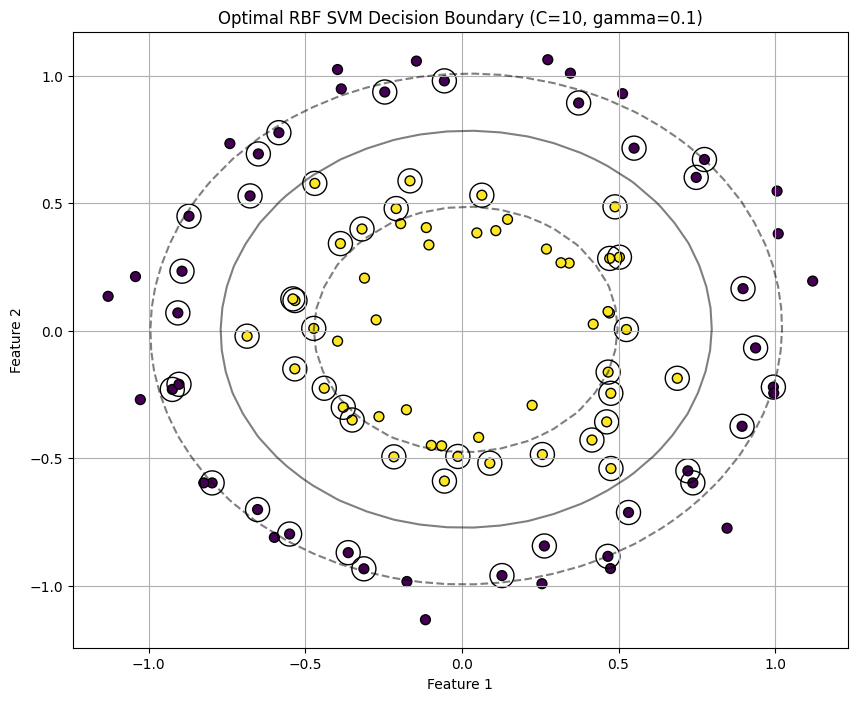

In [13]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 100],
    'kernel': ['rbf']
}

# Create an SVM model
svc_grid = SVC(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(svc_grid, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_nonlinear, y_nonlinear)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.2f}")

# Get the best model
best_svc = grid_search.best_estimator_

plt.figure(figsize=(10, 8))
plt.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, s=50, cmap='viridis', edgecolor='k')
plot_svc_decision_function(best_svc) # Visualize decision boundary of the best model
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Optimal RBF SVM Decision Boundary (C={best_svc.C}, gamma={best_svc.gamma:.1f})')
plt.grid(True)
plt.show()


### Explanation of Hyperparameter Tuning:

*   `GridSearchCV` systematically explored all combinations of `C` and `gamma` specified in `param_grid`.
*   For each combination, it performed 5-fold cross-validation (`cv=5`) to get a robust estimate of the model's performance (`scoring='accuracy'`).
*   It then identified the `best_params_` (the combination of `C` and `gamma` that yielded the highest average accuracy across the folds) and the `best_score_`.
*   Finally, we visualized the decision boundary of this `best_estimator_`, which should provide the most balanced and effective separation for the given data and hyperparameter range.

## 8. Advantages and Disadvantages of SVM

### Advantages:

*   **Effective in High-Dimensional Spaces**: SVMs are very effective in scenarios where the number of features is greater than the number of samples.
*   **Memory Efficient**: They use a subset of training points in the decision function (support vectors), making them memory efficient.
*   **Versatile Kernels**: Different kernel functions can be specified for the decision function, making them applicable to a wide range of problems.
*   **Clear Margin of Separation**: When a clear margin of separation exists, SVM performs well.

### Disadvantages:

*   **Computational Cost**: SVMs can be computationally expensive to train, especially on large datasets, as the training time complexity can be between $O(n_{samples}^2)$ and $O(n_{samples}^3)$.
*   **Sensitive to Parameter Choice**: The performance of SVM is highly dependent on the choice of kernel function and the tuning of hyperparameters (`C`, `gamma`, `epsilon`).
*   **Difficulty with Large Datasets**: Due to high training time, SVMs are less suitable for very large datasets.
*   **Lack of Probabilistic Outputs**: Unlike some other classifiers (e.g., Logistic Regression), standard SVMs do not directly provide probability estimates for class membership. While `SVC` in scikit-learn can output probabilities, it's typically done via an expensive 5-fold cross-validation calculation.

## 9. Practical Considerations

When working with SVMs in a real-world scenario, keep the following in mind:

*   **Feature Scaling**: SVMs are sensitive to feature scaling. It's almost always a good idea to scale your data (e.g., using `StandardScaler` or `MinMaxScaler`) before training an SVM.
*   **Choice of Kernel**: Start with the RBF kernel. It's a good general-purpose kernel. If you have prior knowledge about the data structure (e.g., linear separability), you might try linear or polynomial kernels.
*   **Hyperparameter Tuning**: Always tune hyperparameters using cross-validation. This is crucial for optimizing model performance and preventing overfitting.
*   **Handling Large Datasets**: For very large datasets, consider using `LinearSVC` (which is implemented in terms of `liblinear` and is faster for linear cases) or `SGDClassifier` with `loss='hinge'` (Stochastic Gradient Descent classifier with a linear SVM loss function) which can scale to millions of samples.

## Conclusion

This comprehensive guide has walked you through the core concepts of Support Vector Machines, from their basic idea of maximizing margins to handling non-linear data with the kernel trick, multi-class classification strategies, and even extending to regression tasks with SVR. We've also delved into the critical role of hyperparameters like `C` and `gamma` and demonstrated how to tune them effectively using `GridSearchCV`.

SVMs are powerful and versatile algorithms that, when properly understood and tuned, can deliver excellent performance across a wide range of machine learning problems. This hands-on explanation with visualizations should provide a solid foundation for teaching and applying SVMs in various industry scenarios.

## 6. Support Vector Regression (SVR)

Just as Support Vector Machines (SVMs) can be used for classification, their principles can also be extended to solve regression problems, in which case they are called **Support Vector Regression (SVR)**. The core idea is similar: instead of trying to fit the largest possible street between two classes, SVR tries to fit as many instances as possible within an 'epsilon' margin while limiting margin violations (i.e., data points outside the margin).

### Key Concepts of SVR:

*   **Epsilon ($\epsilon$)**: This parameter defines a margin of tolerance around the predicted value. No penalty is associated with errors within this margin. This is a unique feature of SVR, aiming to find a function that deviates from the training data by no more than $\epsilon$.
*   **C Parameter**: Similar to SVC, `C` is a regularization parameter that controls the trade-off between the flatness of the function (avoiding overfitting) and the amount of error tolerance (allowing points outside the $\epsilon$-tube).
*   **Kernel Trick**: SVR also benefits from the kernel trick, allowing it to model non-linear relationships, just like SVC.

### 6.1. Example: SVR with Synthetic Data

Let's create some simple synthetic data and fit an SVR model to it.

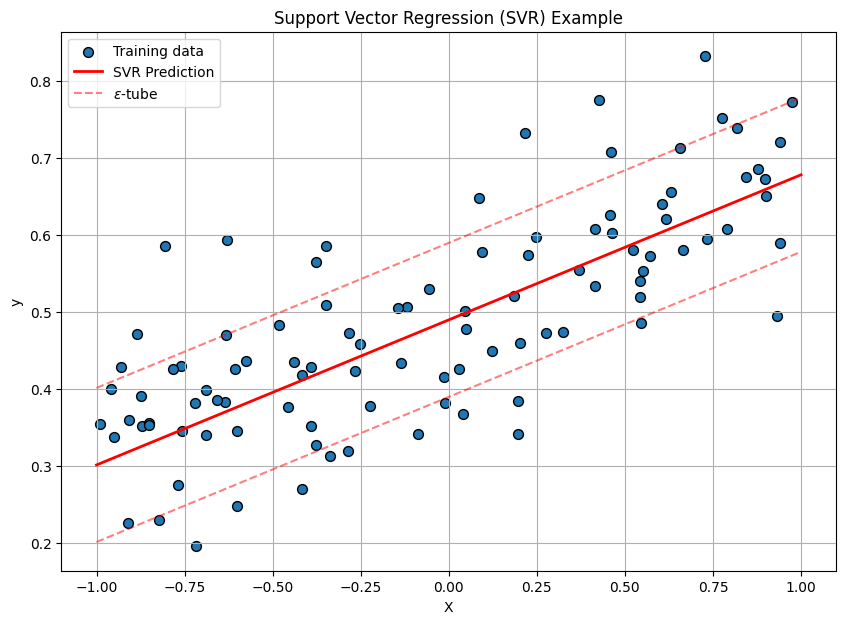

In [17]:
from sklearn.svm import SVR

# Generate some synthetic data for regression
np.random.seed(42)
X_reg = 2 * np.random.rand(100, 1) - 1
y_reg = (0.5 + 0.2 * X_reg + np.random.randn(100, 1) * 0.1).ravel()

# Fit an SVR model
svr_linear = SVR(kernel='linear', C=100, epsilon=0.1) # C and epsilon are hyperparameters
svr_linear.fit(X_reg, y_reg)

# Predict over a range to visualize the function
X_test_reg = np.linspace(-1, 1, 100).reshape(-1, 1)
y_pred_reg = svr_linear.predict(X_test_reg)

plt.figure(figsize=(10, 7))
plt.scatter(X_reg, y_reg, s=50, edgecolors='k', label='Training data')
plt.plot(X_test_reg, y_pred_reg, color='red', linewidth=2, label='SVR Prediction')

# Plot the epsilon-insensitive tube
plt.plot(X_test_reg, y_pred_reg + svr_linear.epsilon, 'r--', alpha=0.5, label=r'$\epsilon$-tube')
plt.plot(X_test_reg, y_pred_reg - svr_linear.epsilon, 'r--', alpha=0.5)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Support Vector Regression (SVR) Example')
plt.legend()
plt.grid(True)
plt.show()

### Explanation of the SVR Plot:

*   The **red line** represents the SVR model's prediction function.
*   The **red dashed lines** define the $\epsilon$-insensitive tube. SVR tries to fit the data such that as many data points as possible fall within this tube. Errors outside this tube are penalized.
*   The `epsilon` parameter controls the width of this tube. A larger $\epsilon$ means a wider tube, allowing more errors without penalty, leading to a flatter model. A smaller $\epsilon$ means a narrower tube, making the model more sensitive to individual data points.

SVR can also use different kernels (e.g., 'rbf', 'poly') to model non-linear relationships, making it a versatile tool for various regression tasks.

## 7. Hyperparameter Tuning for SVM

As we've seen, SVM models have several hyperparameters (`C`, `gamma`, `epsilon`, `kernel`, etc.) that significantly impact their performance. Finding the optimal combination of these parameters is crucial for building an effective SVM model. This process is known as **hyperparameter tuning**.

Common strategies for hyperparameter tuning include:

1.  **Grid Search Cross-Validation (`GridSearchCV`)**:
    *   This method exhaustively searches through a manually specified subset of the hyperparameter space.
    *   For each combination of hyperparameters, it trains and evaluates the model using cross-validation.
    *   The combination that yields the best performance (e.g., highest accuracy or lowest error) is selected.
    *   It is computationally expensive, especially with many hyperparameters or large ranges.

2.  **Randomized Search Cross-Validation (`RandomizedSearchCV`)**:
    *   Instead of trying all possible combinations, `RandomizedSearchCV` samples a fixed number of hyperparameter settings from a specified distribution.
    *   This can be more efficient than `GridSearchCV` when the search space is large, as it often finds a good combination much faster.

Let's demonstrate `GridSearchCV` to find the best `C` and `gamma` for our non-linear classification example (concentric circles).

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters found: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation accuracy: 1.00


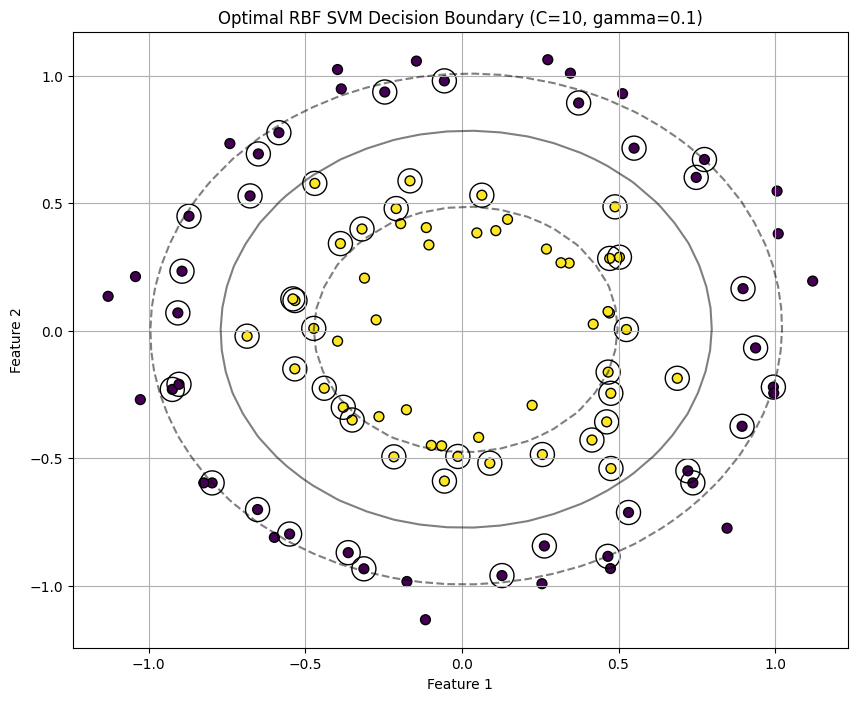

In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 1, 10, 100],
    'kernel': ['rbf']
}

# Create an SVM model
svc_grid = SVC(random_state=42)

# Create the GridSearchCV object
grid_search = GridSearchCV(svc_grid, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_nonlinear, y_nonlinear)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.2f}")

# Get the best model
best_svc = grid_search.best_estimator_

plt.figure(figsize=(10, 8))
plt.scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=y_nonlinear, s=50, cmap='viridis', edgecolor='k')
plot_svc_decision_function(best_svc) # Visualize decision boundary of the best model
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Optimal RBF SVM Decision Boundary (C={best_svc.C}, gamma={best_svc.gamma:.1f})')
plt.grid(True)
plt.show()


### Explanation of Hyperparameter Tuning:

*   `GridSearchCV` systematically explored all combinations of `C` and `gamma` specified in `param_grid`.
*   For each combination, it performed 5-fold cross-validation (`cv=5`) to get a robust estimate of the model's performance (`scoring='accuracy'`).
*   It then identified the `best_params_` (the combination of `C` and `gamma` that yielded the highest average accuracy across the folds) and the `best_score_`.
*   Finally, we visualized the decision boundary of this `best_estimator_`, which should provide the most balanced and effective separation for the given data and hyperparameter range.

## 8. Advantages and Disadvantages of SVM

### Advantages:

*   **Effective in High-Dimensional Spaces**: SVMs are very effective in scenarios where the number of features is greater than the number of samples.
*   **Memory Efficient**: They use a subset of training points in the decision function (support vectors), making them memory efficient.
*   **Versatile Kernels**: Different kernel functions can be specified for the decision function, making them applicable to a wide range of problems.
*   **Clear Margin of Separation**: When a clear margin of separation exists, SVM performs well.

### Disadvantages:

*   **Computational Cost**: SVMs can be computationally expensive to train, especially on large datasets, as the training time complexity can be between $O(n_{samples}^2)$ and $O(n_{samples}^3)$.
*   **Sensitive to Parameter Choice**: The performance of SVM is highly dependent on the choice of kernel function and the tuning of hyperparameters (`C`, `gamma`, `epsilon`).
*   **Difficulty with Large Datasets**: Due to high training time, SVMs are less suitable for very large datasets.
*   **Lack of Probabilistic Outputs**: Unlike some other classifiers (e.g., Logistic Regression), standard SVMs do not directly provide probability estimates for class membership. While `SVC` in scikit-learn can output probabilities, it's typically done via an expensive 5-fold cross-validation calculation.

## 9. Practical Considerations

When working with SVMs in a real-world scenario, keep the following in mind:

*   **Feature Scaling**: SVMs are sensitive to feature scaling. It's almost always a good idea to scale your data (e.g., using `StandardScaler` or `MinMaxScaler`) before training an SVM.
*   **Choice of Kernel**: Start with the RBF kernel. It's a good general-purpose kernel. If you have prior knowledge about the data structure (e.g., linear separability), you might try linear or polynomial kernels.
*   **Hyperparameter Tuning**: Always tune hyperparameters using cross-validation. This is crucial for optimizing model performance and preventing overfitting.
*   **Handling Large Datasets**: For very large datasets, consider using `LinearSVC` (which is implemented in terms of `liblinear` and is faster for linear cases) or `SGDClassifier` with `loss='hinge'` (Stochastic Gradient Descent classifier with a linear SVM loss function) which can scale to millions of samples.

## Conclusion

This comprehensive guide has walked you through the core concepts of Support Vector Machines, from their basic idea of maximizing margins to handling non-linear data with the kernel trick, multi-class classification strategies, and even extending to regression tasks with SVR. We've also delved into the critical role of hyperparameters like `C` and `gamma` and demonstrated how to tune them effectively using `GridSearchCV`.

SVMs are powerful and versatile algorithms that, when properly understood and tuned, can deliver excellent performance across a wide range of machine learning problems. This hands-on explanation with visualizations should provide a solid foundation for teaching and applying SVMs in various industry scenarios.

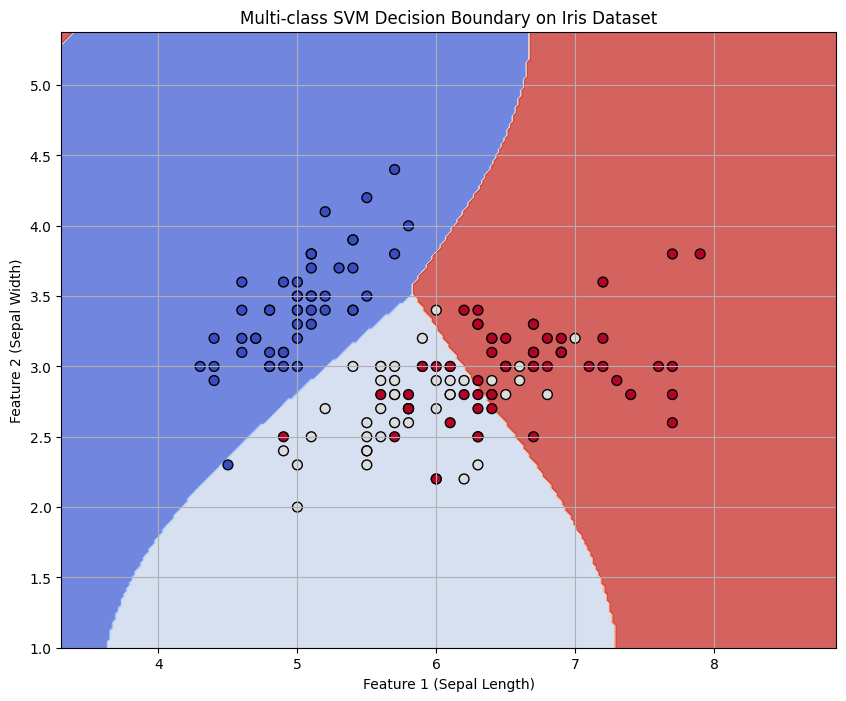

In [11]:
def plot_multiclass_decision_boundary(model, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=50, edgecolor='k')
    plt.xlabel('Feature 1 (Sepal Length)')
    plt.ylabel('Feature 2 (Sepal Width)')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_multiclass_decision_boundary(svm_multi, X_iris, y_iris, 'Multi-class SVM Decision Boundary on Iris Dataset')
